In [1]:
SCOPETYPE = 'OPENADC'
PLATFORM = 'CW303'
CRYPTO_TARGET='TINYAES128C'
SS_VER='SS_VER_2_1'
%run "jupyter/Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 11875301                  to 38221960                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 64960716                 
scope.clock.adc_rate                     changed from 0.0                       to 64960716.0        

In [2]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER"
cd firmware/mcu/simpleserial-aes
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3 -j

Building for platform CW303 with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CW303 
.
Welcome to another exciting ChipWhisperer target build!!
.
.
.
Compiling:
.
Compiling:
Compiling:
-en     simpleserial-aes.c ...
Compiling:
-en     .././simpleserial/simpleserial.c ...
-en     .././hal/hal.c ...
-en     .././hal//xmega/XMEGA_AES_driver.c ...
.
.
.
Compiling:
Compiling:
.
Compiling:
-en     .././hal//xmega/uart.c ...
-en     .././hal//xmega/usart_driver.c ...
Compiling:
.
-en     .././hal//xmega/xmega_hal.c ...
Compiling:
-en     .././crypto/tiny-AES128-C/aes.c ...
-en     .././crypto/aes-independant.c ...
-e Done!
-e Done!
-e Done!
-e Done!
-e Done!
-e Done!
-e Done!
-e Done!
-e

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4431 bytes


CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')


Capturing traces:   0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/199 [00:00<?, ?it/s]

Best Key Guess: 2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c 

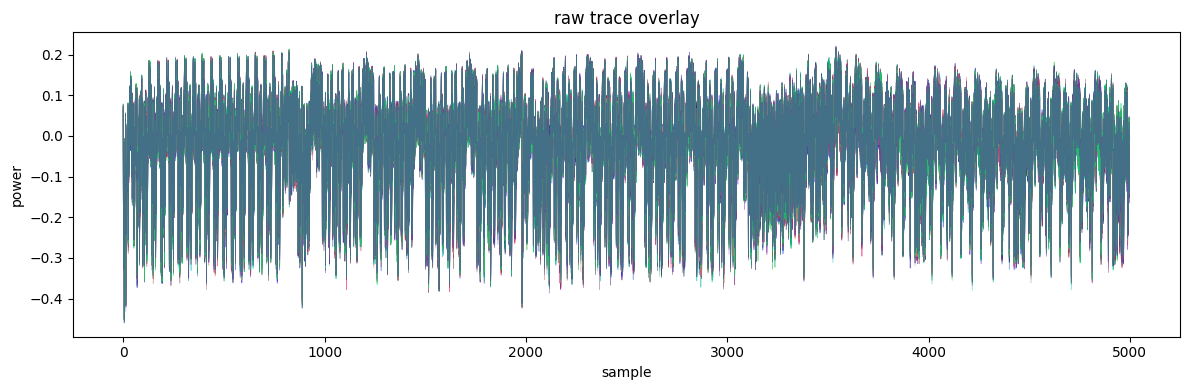

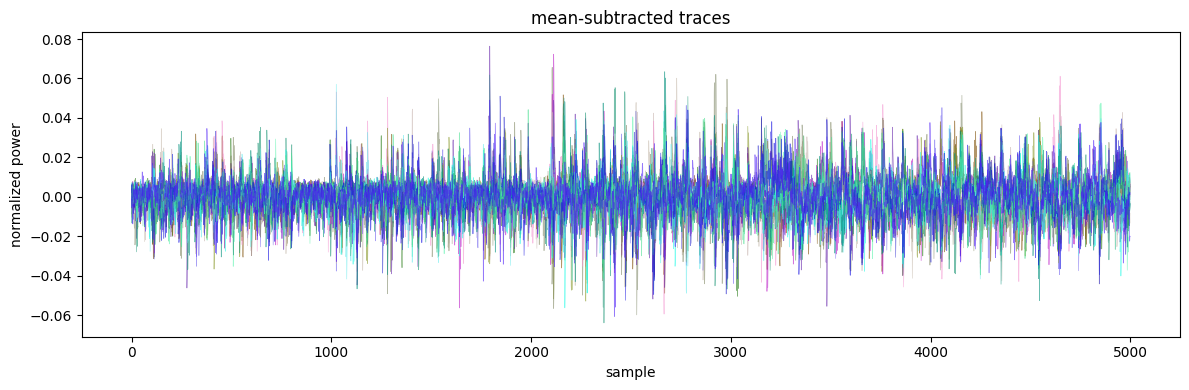

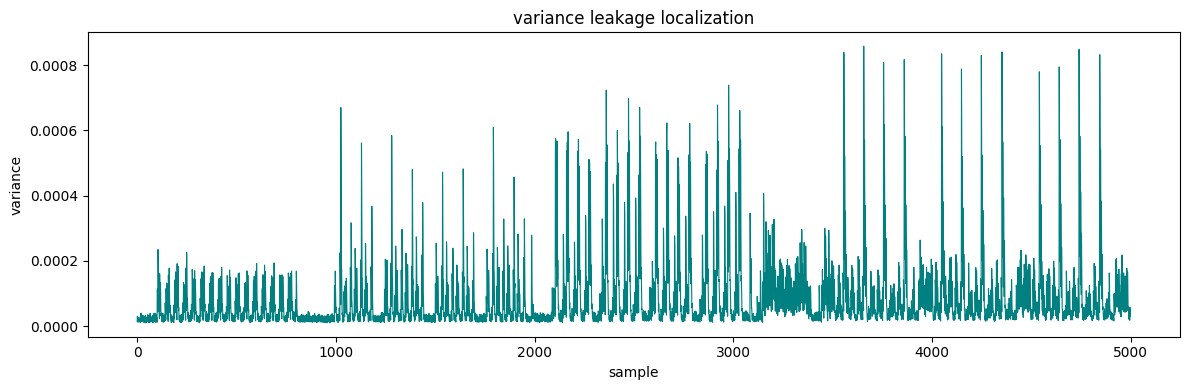

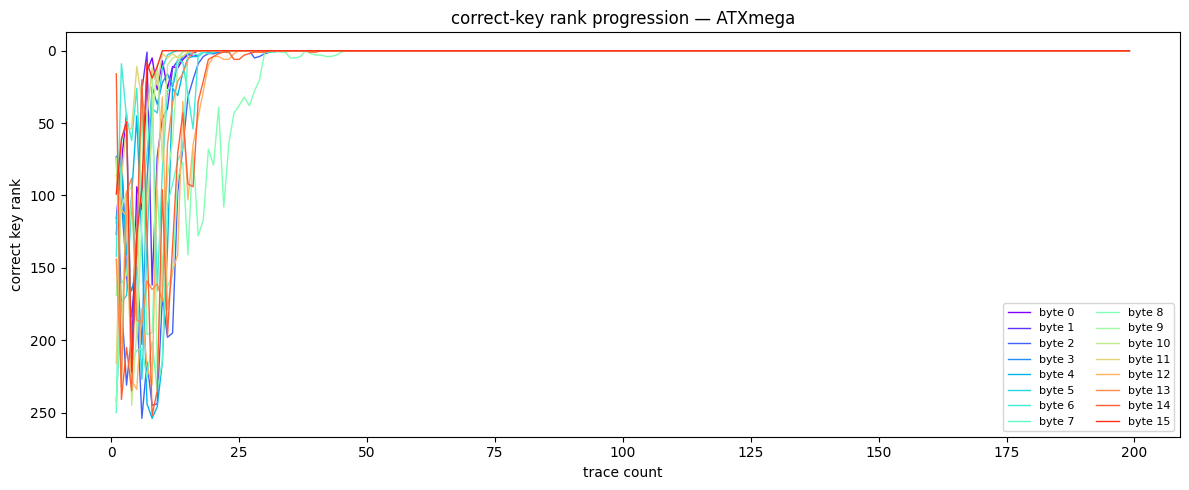

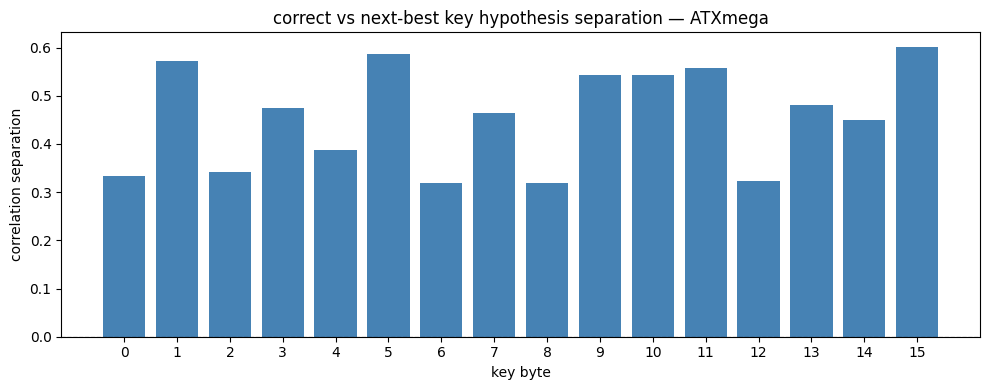

In [3]:
cw.program_target(scope, prog, "firmware/mcu/simpleserial-aes/simpleserial-aes-{}.hex".format(PLATFORM))
splot = cw.StreamPlot()
splot.plot()

from tqdm.notebook import trange
import numpy as np
import chipwhisperer as cw
import matplotlib.pyplot as plt
%matplotlib inline

# Capture
ktp = cw.ktp.Basic()
trace_array = []
textin_array = []

key, text = ktp.next()
print(key)
target.set_key(key)

N = 200
for i in trange(N, desc='Capturing traces'):
    scope.arm()
    target.simpleserial_write('p', text)
    ret = scope.capture()
    if ret:
        print("Target timed out!")
        continue
    response = target.simpleserial_read('r', 16)
    trace_array.append(scope.get_last_trace())
    textin_array.append(text)
    key, text = ktp.next()
    splot.update(scope.get_last_trace())

trace_array = np.array(trace_array)[1:, 0:5000]
textin_array = textin_array[1:]
scope.dis()
target.dis()

# SubBytes
sbox = [
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
]

HW = [bin(i).count('1') for i in range(256)]

def aes_internal(inputdata, key):
    return sbox[(inputdata ^ key) & 0xFF]

def mean(X):     return np.sum(X, axis=0) / len(X)
def std_dev(X, X_bar): return np.sum((X - X_bar)**2, axis=0) ** 0.5
def cov(X, X_bar, Y, Y_bar): return np.sum((Y - Y_bar) * (X - X_bar), axis=0)

# Known key
correct_key = [0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6,
               0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c]

N_actual = len(trace_array)

from joblib import Parallel, delayed

def cpa_at_n(n):
    t      = trace_array[:n]
    t_bar  = mean(t)
    t_cent = t - t_bar

    ranks_n = np.zeros(16, dtype=np.int32)
    maxcpa_n = np.zeros((16, 256))

    for bnum in range(16):
        hws     = np.array([[HW[aes_internal(textin[bnum], k)]
                             for textin in textin_array[:n]]
                            for k in range(256)], dtype=float)  # (256, n)
        hws_bar = hws.mean(axis=1, keepdims=True)
        h_cent  = hws - hws_bar

        num    = h_cent @ t_cent
        denom  = np.sqrt((h_cent**2).sum(axis=1, keepdims=True)) * std_dev(t, t_bar)
        maxcpa = np.max(np.abs(num / (denom + 1e-10)), axis=1)

        order = np.argsort(maxcpa)[::-1]
        ranks_n[bnum]   = np.where(order == correct_key[bnum])[0][0]
        maxcpa_n[bnum]  = maxcpa

    return n, ranks_n, maxcpa_n

results = Parallel(n_jobs=-1)(delayed(cpa_at_n)(n) for n in trange(1, N_actual + 1))

ranks_over_traces = np.zeros((16, N_actual), dtype=np.int32)
for n, ranks_n, maxcpa_n in results:
    ranks_over_traces[:, n-1] = ranks_n

_, _, final_maxcpa = results[-1]
bestguess = [int(np.argsort(final_maxcpa[b])[::-1][0]) for b in range(16)]
print("Best Key Guess: ", end="")
for b in bestguess: print("%02x " % b, end="")

# separation
separations = [
    final_maxcpa[b, correct_key[b]] - np.max(np.delete(final_maxcpa[b], correct_key[b]))
    for b in range(16)
]

# Plot: raw trace overlay (replace the mean-subtracted block)
fig, ax = plt.subplots(figsize=(12, 4))
for trace in trace_array[:20]:
    ax.plot(trace, color=np.random.rand(3), alpha=0.6, linewidth=0.5)
ax.set(xlabel='sample', ylabel='power', title='raw trace overlay')
plt.tight_layout(); plt.show()

# Plot: mean-subtracted traces
fig, ax = plt.subplots(figsize=(12, 4))
for trace in (trace_array - np.mean(trace_array, axis=0))[:20]:
    ax.plot(trace, color=np.random.rand(3), alpha=0.6, linewidth=0.5)
ax.set(xlabel='sample', ylabel='normalized power', title='mean-subtracted traces')
plt.tight_layout(); plt.show()

# Plot: variance leakage localization
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.var(trace_array, axis=0), color='teal', linewidth=0.8)
ax.set(xlabel='sample', ylabel='variance', title='variance leakage localization')
plt.tight_layout(); plt.show()

# Plot: correct-key rank over trace count
fig, ax = plt.subplots(figsize=(12, 5))
for bnum in range(16):
    ax.plot(np.arange(1, N_actual + 1), ranks_over_traces[bnum],
            color=plt.cm.rainbow(bnum / 16), linewidth=1, label=f'byte {bnum}')
ax.set(xlabel='trace count', ylabel='correct key rank',
       title='correct-key rank progression — ATXmega')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# Plot: correlation separation per key byte
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(16), separations,
       color=['crimson' if s < 0 else 'steelblue' for s in separations])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(xlabel='key byte', ylabel='correlation separation',
       title='correct vs next-best key hypothesis separation — ATXmega')
ax.set_xticks(range(16))
plt.tight_layout(); plt.show()